In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving canada_per_capita_income.csv to canada_per_capita_income.csv


In [3]:
df = pd.read_csv('canada_per_capita_income.csv')
df.head()

,year,per capita income (US$)
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583


In [4]:
.df.rename(columns={'per capita income (US$)': 'per_capita_income'}, inplace=True)
print(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               47 non-null     int64  
 1   per_capita_income  47 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 884.0 bytes
None


,year,per_capita_income
count,47.000000,47.000000
mean,1993.000000,18920.137063
std,13.711309,12034.679438
min,1970.000000,3399.299037
25%,1981.500000,9526.914515
50%,1993.000000,16426.725480
75%,2004.500000,27458.601420
max,2016.000000,42676.468370


In [5]:
median_income = df['per_capita_income'].median()
df['income_above_median'] = (df['per_capita_income'] > median_income).astype(int)

display(df.head())

,year,per_capita_income,income_above_median
0,1970,3399.299037,0
1,1971,3768.297935,0
2,1972,4251.175484,0
3,1973,4804.463248,0
4,1974,5576.514583,0


In [6]:
from sklearn.model_selection import train_test_split

X = df[['year']]
y = df['income_above_median']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (32, 1)
X_test shape: (15, 1)
y_train shape: (32,)
y_test shape: (15,)


Model Accuracy: 0.8666666666666667

Confusion Matrix:
 [[6 2]
 [0 7]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.75      0.86         8
           1       0.78      1.00      0.88         7

    accuracy                           0.87        15
   macro avg       0.89      0.88      0.87        15
weighted avg       0.90      0.87      0.87        15



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


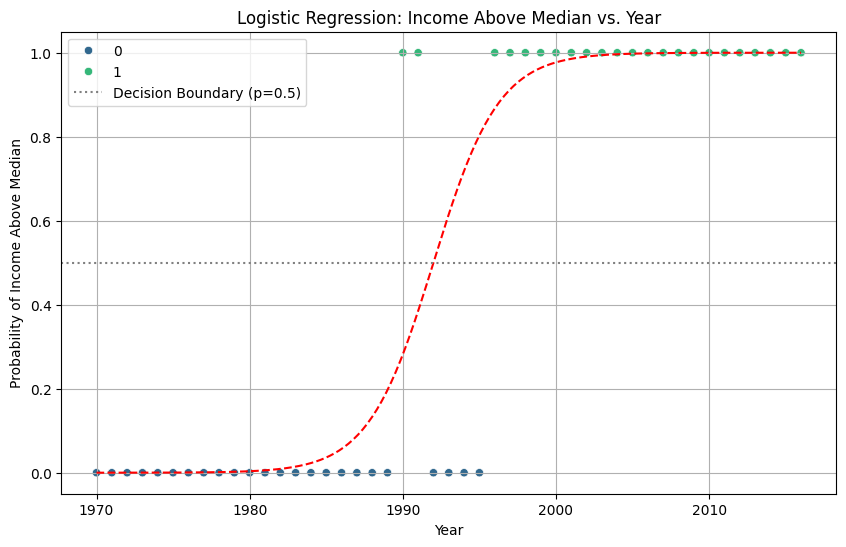

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['year'], y=df['income_above_median'], hue=df['income_above_median'], palette='viridis', legend='full')

min_year = X['year'].min()
max_year = X['year'].max()
years_for_plot = np.linspace(min_year, max_year, 300).reshape(-1, 1)
probabilities = model.predict_proba(years_for_plot)[:, 1]

plt.plot(years_for_plot, probabilities, color='red', linestyle='--')
plt.axhline(0.5, color='gray', linestyle=':', label='Decision Boundary (p=0.5)')
plt.title('Logistic Regression: Income Above Median vs. Year')
plt.xlabel('Year')
plt.ylabel('Probability of Income Above Median')
plt.grid(True)
plt.legend()
plt.show()

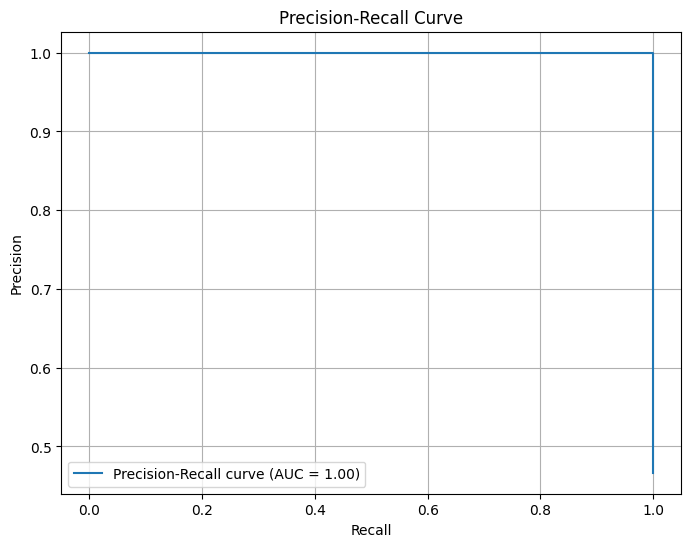

In [8]:
from sklearn.metrics import precision_recall_curve, auc

y_scores = model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()